# Day 1 – Linear Algebra for Machine Learning
### 20-Day ML Revision Planner | Phase: Mathematical Foundation

**Daily Target:** 60 min Mathematics + 30 min Coding practice woven into theory + 30 min Interview Prep + 30 min Active Recall

**Topics covered:**
1. Scalars, Vectors, and Matrices
2. Vector Addition and Scalar Multiplication
3. Dot Product and Matrix Multiplication
4. Transpose, Identity Matrix, and Inverse
5. Rank and Linear Independence
6. L1 and L2 Norms
7. ML Connections (dataset as matrix, distance & similarity)
8. Coding Practice (NumPy)
9. Interview Questions
10. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
print("NumPy version:", np.__version__)


NumPy version: 2.4.4


## 1. Scalars, Vectors, and Matrices

### What?
- **Scalar**: a single number. E.g. $a = 5$. Has magnitude only, no direction.
- **Vector**: an ordered array of numbers, representing a point or direction in space.
  $$\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix} \in \mathbb{R}^n$$
- **Matrix**: a 2D array of numbers arranged in rows and columns.
  $$A \in \mathbb{R}^{m \times n}$$
  where $m$ = number of rows, $n$ = number of columns.

### Why?
Almost everything in ML is represented using these objects:
- A single feature value → scalar
- A single data sample (all its features) → vector
- An entire dataset (samples × features) → matrix
- A batch of images → higher-dimensional array (tensor)

### How?
- A vector of length $n$ lives in $n$-dimensional space.
- A matrix can be viewed as a *collection of vectors* (its columns, or its rows).
- Shape compatibility is crucial: operations like addition require matching shapes; multiplication requires matching inner dimensions.

### ML Connection
- **Dataset as a matrix**: rows = samples, columns = features. If you have 100 samples with 5 features each, your data matrix $X \in \mathbb{R}^{100 \times 5}$.
- **Model parameters as a vector**: e.g., in linear regression, weights $\mathbf{w} \in \mathbb{R}^n$.


In [2]:
# Scalars, Vectors, Matrices in NumPy

scalar = 5
vector = np.array([1, 2, 3])
matrix = np.array([[1, 2, 3],
                    [4, 5, 6]])

print("Scalar:", scalar, "| type:", type(scalar))
print("Vector:", vector, "| shape:", vector.shape)
print("Matrix:\n", matrix, "\n| shape:", matrix.shape)

# A toy "dataset" - 4 samples, 3 features
X = np.array([
    [5.1, 3.5, 1.4],
    [4.9, 3.0, 1.4],
    [6.2, 3.4, 5.4],
    [5.9, 3.0, 5.1]
])
print("\nDataset matrix X (samples x features):\n", X)
print("Number of samples:", X.shape[0], "| Number of features:", X.shape[1])


Scalar: 5 | type: <class 'int'>
Vector: [1 2 3] | shape: (3,)
Matrix:
 [[1 2 3]
 [4 5 6]] 
| shape: (2, 3)

Dataset matrix X (samples x features):
 [[5.1 3.5 1.4]
 [4.9 3.  1.4]
 [6.2 3.4 5.4]
 [5.9 3.  5.1]]
Number of samples: 4 | Number of features: 3


## 2. Vector Addition and Scalar Multiplication

### What?
- **Vector addition**: element-wise sum of two vectors of the same shape.
  $$\mathbf{a} + \mathbf{b} = \begin{bmatrix} a_1+b_1 \\ a_2+b_2 \\ \vdots \end{bmatrix}$$
- **Scalar multiplication**: multiply every element of a vector by a scalar.
  $$c \cdot \mathbf{a} = \begin{bmatrix} c a_1 \\ c a_2 \\ \vdots \end{bmatrix}$$

### Why?
- Gradient descent updates parameters using exactly this: `weights = weights - learning_rate * gradient`, which is a scalar multiplication followed by vector subtraction.
- Combining feature vectors (e.g., averaging, weighted sums) uses these operations.

### How?
Both operations are element-wise, so shapes must match for addition (or be broadcastable in NumPy).


a + b = [5 7 9]
a - b = [-3 -3 -3]
3 * a = [3 6 9]
a / 2 = [0.5 1.  1.5]


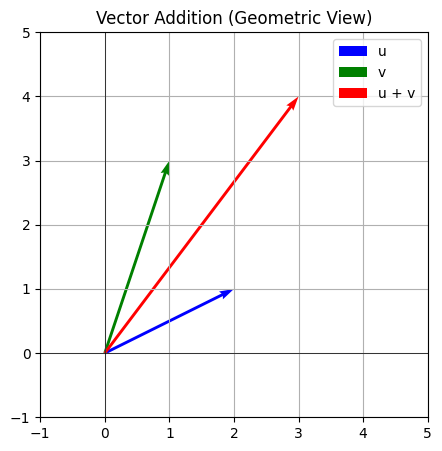

In [3]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("a + b =", a + b)
print("a - b =", a - b)
print("3 * a =", 3 * a)
print("a / 2 =", a / 2)

# Geometric visualization of vector addition (2D)
u = np.array([2, 1])
v = np.array([1, 3])
w = u + v

plt.figure(figsize=(5, 5))
plt.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1, color='b', label='u')
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='g', label='v')
plt.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='r', label='u + v')
plt.xlim(-1, 5); plt.ylim(-1, 5)
plt.grid(True); plt.legend(); plt.title("Vector Addition (Geometric View)")
plt.axhline(0, color='black', linewidth=0.5); plt.axvline(0, color='black', linewidth=0.5)
plt.show()


## 3. Dot Product and Matrix Multiplication

### What?
- **Dot product** (inner product) of two vectors of the same length:
  $$\mathbf{a} \cdot \mathbf{b} = \sum_i a_i b_i$$
  Result is a **scalar**.
- **Matrix multiplication**: for $A \in \mathbb{R}^{m \times n}$ and $B \in \mathbb{R}^{n \times p}$, the product $C = AB \in \mathbb{R}^{m \times p}$ where
  $$C_{ij} = \sum_k A_{ik} B_{kj}$$

### Why?
- Dot product measures **similarity/alignment** between vectors — it's the mathematical basis of cosine similarity, correlation, and neuron activations ($\mathbf{w}^T \mathbf{x} + b$).
- Matrix multiplication is how a whole **batch of samples** is passed through a linear model in one shot: $\hat{y} = Xw$.

### How?
- Dot product: multiply corresponding elements, then sum.
- Matrix multiplication: **inner dimensions must match** ($n$ in the example above). Each output entry is a dot product of a row of $A$ with a column of $B$.
- Matrix multiplication is **not commutative**: $AB \neq BA$ in general.

### ML Connection
- A linear model's prediction step, $\hat{y} = Xw + b$, is literally a matrix–vector multiplication.
- Neural network forward passes are chains of matrix multiplications followed by non-linear activations.


In [4]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

dot_manual = sum(ai * bi for ai, bi in zip(a, b))
dot_numpy = np.dot(a, b)          # or a @ b
print("Dot product (manual):", dot_manual)
print("Dot product (numpy):", dot_numpy)
print("Dot product (@ operator):", a @ b)

A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print("\nMatrix A:\n", A)
print("Matrix B:\n", B)
print("\nA @ B =\n", A @ B)
print("B @ A =\n", B @ A, "  <-- note: different from A @ B (not commutative)")

# Linear model prediction as matrix multiplication
X_batch = np.array([[1, 2], [3, 4], [5, 6]])   # 3 samples, 2 features
w = np.array([0.5, -0.2])                       # weights
bias = 1.0
predictions = X_batch @ w + bias
print("\nBatch predictions (Xw + b):", predictions)


Dot product (manual): 32
Dot product (numpy): 32
Dot product (@ operator): 32

Matrix A:
 [[1 2]
 [3 4]]
Matrix B:
 [[5 6]
 [7 8]]

A @ B =
 [[19 22]
 [43 50]]
B @ A =
 [[23 34]
 [31 46]]   <-- note: different from A @ B (not commutative)

Batch predictions (Xw + b): [1.1 1.7 2.3]


## 4. Transpose, Identity Matrix, and Inverse

### What?
- **Transpose** ($A^T$): flips a matrix over its diagonal — rows become columns.
- **Identity matrix** ($I$): a square matrix with 1s on the diagonal and 0s elsewhere. Acts like the number "1" for matrices: $AI = IA = A$.
- **Inverse** ($A^{-1}$): for a square matrix $A$, the inverse satisfies $A A^{-1} = A^{-1} A = I$. Not every matrix has an inverse (must be square and non-singular, i.e., $\det(A) \neq 0$).

### Why?
- Transpose is used constantly, e.g., $\mathbf{w}^T \mathbf{x}$, or reshaping data for matrix multiplication compatibility.
- The **Normal Equation** for linear regression uses the inverse:
  $$\mathbf{w} = (X^T X)^{-1} X^T y$$
- Identity matrix appears in regularization: Ridge regression adds $\lambda I$ to $X^TX$ before inverting.

### How?
- If $\det(A) = 0$, the matrix is **singular** and has no inverse (this happens with multicollinear features — a key reason regularization is needed).


In [5]:
A = np.array([[4, 7], [2, 6]])
print("A:\n", A)
print("A transpose:\n", A.T)

I = np.eye(2)
print("\nIdentity matrix I:\n", I)
print("A @ I =\n", A @ I, "  <-- equals A")

A_inv = np.linalg.inv(A)
print("\nA inverse:\n", A_inv)
print("A @ A_inv (should be ~I):\n", A @ A_inv)

# Determinant check - singular matrix example
singular = np.array([[1, 2], [2, 4]])   # second row = 2 * first row
print("\nDeterminant of singular matrix:", np.linalg.det(singular))
try:
    np.linalg.inv(singular)
except np.linalg.LinAlgError as e:
    print("Inversion failed as expected:", e)

# Normal Equation demo: w = (X^T X)^-1 X^T y
X = np.array([[1, 1], [1, 2], [1, 3]])   # column of 1s for bias + one feature
y = np.array([2, 4, 6])
w = np.linalg.inv(X.T @ X) @ X.T @ y
print("\nNormal Equation solution (bias, slope):", w)


A:
 [[4 7]
 [2 6]]
A transpose:
 [[4 2]
 [7 6]]

Identity matrix I:
 [[1. 0.]
 [0. 1.]]
A @ I =
 [[4. 7.]
 [2. 6.]]   <-- equals A

A inverse:
 [[ 0.6 -0.7]
 [-0.2  0.4]]
A @ A_inv (should be ~I):
 [[ 1. -0.]
 [-0.  1.]]

Determinant of singular matrix: 0.0
Inversion failed as expected: Singular matrix

Normal Equation solution (bias, slope): [-0.  2.]


## 5. Rank and Linear Independence

### What?
- A set of vectors is **linearly independent** if no vector in the set can be written as a combination of the others.
- The **rank** of a matrix is the number of linearly independent rows (or columns) it has — i.e., the dimension of the space its rows/columns span.

### Why?
- If features are linearly dependent (redundant), $X^TX$ becomes singular and the Normal Equation cannot be solved (motivates regularization or dimensionality reduction).
- Rank tells you the "true" number of independent directions of information in your data.

### How?
- `np.linalg.matrix_rank(A)` computes rank numerically (accounts for floating point tolerance).
- Full rank for an $m \times n$ matrix ($m \geq n$) means rank $= n$ (all columns independent).


In [6]:
# Independent columns
A = np.array([[1, 0], [0, 1], [1, 1]])
print("Matrix A:\n", A)
print("Rank of A:", np.linalg.matrix_rank(A), "(full column rank = 2)")

# Dependent columns (second column = 2 * first column)
B = np.array([[1, 2], [2, 4], [3, 6]])
print("\nMatrix B:\n", B)
print("Rank of B:", np.linalg.matrix_rank(B), "(rank-deficient! columns are dependent)")

# Why this matters for ML: multicollinearity
X_redundant = np.array([[1, 2, 4], [2, 3, 6], [3, 5, 10]])  # col3 = 2*col2
print("\nFeature matrix with a redundant (multicollinear) feature:\n", X_redundant)
print("Rank:", np.linalg.matrix_rank(X_redundant), "out of", X_redundant.shape[1], "columns")
print("--> X^T X will be singular or near-singular, causing unstable regression coefficients.")


Matrix A:
 [[1 0]
 [0 1]
 [1 1]]
Rank of A: 2 (full column rank = 2)

Matrix B:
 [[1 2]
 [2 4]
 [3 6]]
Rank of B: 1 (rank-deficient! columns are dependent)

Feature matrix with a redundant (multicollinear) feature:
 [[ 1  2  4]
 [ 2  3  6]
 [ 3  5 10]]
Rank: 2 out of 3 columns
--> X^T X will be singular or near-singular, causing unstable regression coefficients.


## 6. L1 and L2 Norms

### What?
A **norm** measures the "size" or "length" of a vector.
- **L1 norm** (Manhattan norm): sum of absolute values.
  $$\|\mathbf{x}\|_1 = \sum_i |x_i|$$
- **L2 norm** (Euclidean norm): square root of sum of squares.
  $$\|\mathbf{x}\|_2 = \sqrt{\sum_i x_i^2}$$

### Why?
- **Distance metrics**: Euclidean distance (L2) is used in KNN, K-Means.
- **Regularization**: Lasso uses the L1 norm of weights (encourages sparsity — some weights become exactly 0); Ridge uses the (squared) L2 norm (shrinks weights smoothly).
- **Feature/embedding similarity**: cosine similarity is built from the L2 norm.

### How?
- L1 norm treats all deviations linearly → tends to produce sparse solutions.
- L2 norm penalizes large values more (due to squaring) → tends to shrink all weights smoothly rather than zeroing them out.


In [7]:
x = np.array([3, -4, 5])

l1_norm = np.sum(np.abs(x))
l2_norm = np.sqrt(np.sum(x**2))

print("Vector x:", x)
print("L1 norm (manual):", l1_norm, "| via numpy:", np.linalg.norm(x, ord=1))
print("L2 norm (manual):", l2_norm, "| via numpy:", np.linalg.norm(x, ord=2))

# Euclidean distance between two points (used in KNN / K-Means)
p1 = np.array([1, 2])
p2 = np.array([4, 6])
euclidean_dist = np.linalg.norm(p1 - p2)
print("\nEuclidean distance between", p1, "and", p2, "=", euclidean_dist)

# Cosine similarity (built on the L2 norm / dot product)
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

v1 = np.array([1, 2, 3])
v2 = np.array([2, 4, 6])   # same direction as v1, scaled
v3 = np.array([-1, -2, -3])  # opposite direction

print("\nCosine similarity(v1, v2) [same direction]:", cosine_similarity(v1, v2))
print("Cosine similarity(v1, v3) [opposite direction]:", cosine_similarity(v1, v3))


Vector x: [ 3 -4  5]
L1 norm (manual): 12 | via numpy: 12.0
L2 norm (manual): 7.0710678118654755 | via numpy: 7.0710678118654755

Euclidean distance between [1 2] and [4 6] = 5.0

Cosine similarity(v1, v2) [same direction]: 1.0
Cosine similarity(v1, v3) [opposite direction]: -1.0


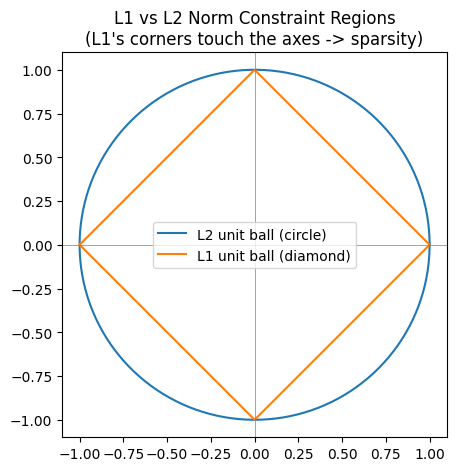

In [8]:
# Visualizing L1 vs L2 "unit balls" — why Lasso induces sparsity
theta = np.linspace(0, 2*np.pi, 300)

# L2 unit circle
l2_x, l2_y = np.cos(theta), np.sin(theta)

# L1 unit "diamond"
t = np.linspace(-1, 1, 300)
l1_x = np.concatenate([t, t[::-1]])
l1_y = np.concatenate([1 - np.abs(t), -(1 - np.abs(t[::-1]))])

plt.figure(figsize=(5, 5))
plt.plot(l2_x, l2_y, label="L2 unit ball (circle)")
plt.plot(l1_x, l1_y, label="L1 unit ball (diamond)")
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.gca().set_aspect('equal')
plt.legend()
plt.title("L1 vs L2 Norm Constraint Regions\n(L1's corners touch the axes -> sparsity)")
plt.show()


## 7. ML Connection Recap

| Concept | ML Usage |
|---|---|
| Dataset as matrix | Rows = samples, columns = features: $X \in \mathbb{R}^{m \times n}$ |
| Model parameters as vector | Weights $\mathbf{w}$, bias $b$ |
| Dot / matrix product | Linear model predictions: $\hat{y} = Xw + b$ |
| Transpose & inverse | Normal Equation: $w = (X^TX)^{-1}X^Ty$ |
| Rank | Detects multicollinearity / redundant features |
| L1 norm | Lasso regularization → sparse weights |
| L2 norm | Ridge regularization, Euclidean distance (KNN, K-Means) |
| Cosine similarity | Text/embedding similarity (uses dot product + L2 norm) |


## 8. Coding Practice — Standalone Exercises

Try to solve each of these **before** looking at Section outputs above. Solutions are provided but implement them from scratch first (without `np.linalg` helper functions) for the ones marked *(from scratch)*.


In [9]:
# Exercise 1 (from scratch): Implement dot product without np.dot
def dot_product_scratch(a, b):
    assert len(a) == len(b), "Vectors must be the same length"
    total = 0
    for ai, bi in zip(a, b):
        total += ai * bi
    return total

a = [1, 2, 3]
b = [4, 5, 6]
print("Scratch dot product:", dot_product_scratch(a, b))
assert dot_product_scratch(a, b) == np.dot(a, b)
print("Matches NumPy result ✔")


Scratch dot product: 32
Matches NumPy result ✔


In [10]:
# Exercise 2 (from scratch): Implement Euclidean distance without np.linalg.norm
def euclidean_distance_scratch(p1, p2):
    return sum((x - y) ** 2 for x, y in zip(p1, p2)) ** 0.5

p1 = [0, 0]
p2 = [3, 4]
print("Scratch Euclidean distance:", euclidean_distance_scratch(p1, p2))
assert np.isclose(euclidean_distance_scratch(p1, p2), np.linalg.norm(np.array(p1) - np.array(p2)))
print("Matches NumPy result ✔  (should be 5.0, the classic 3-4-5 triangle)")


Scratch Euclidean distance: 5.0
Matches NumPy result ✔  (should be 5.0, the classic 3-4-5 triangle)


In [11]:
# Exercise 3: Implement cosine similarity from scratch and test on 3 vector pairs
def cosine_similarity_scratch(a, b):
    dot = dot_product_scratch(a, b)
    norm_a = sum(x**2 for x in a) ** 0.5
    norm_b = sum(x**2 for x in b) ** 0.5
    return dot / (norm_a * norm_b)

pairs = [
    ([1, 0], [0, 1]),     # orthogonal -> 0
    ([1, 1], [1, 1]),     # identical direction -> 1
    ([1, 1], [-1, -1]),   # opposite direction -> -1
]
for va, vb in pairs:
    print(f"cos_sim({va}, {vb}) = {cosine_similarity_scratch(va, vb):.2f}")


cos_sim([1, 0], [0, 1]) = 0.00
cos_sim([1, 1], [1, 1]) = 1.00
cos_sim([1, 1], [-1, -1]) = -1.00


In [12]:
# Exercise 4: Given a small feature matrix, check for multicollinearity via rank
X_check = np.array([
    [1, 2, 5],
    [2, 4, 3],
    [3, 6, 8],
])
rank = np.linalg.matrix_rank(X_check)
n_cols = X_check.shape[1]
print(f"Matrix rank: {rank} / {n_cols} columns")
if rank < n_cols:
    print("⚠️  Multicollinearity detected — at least one feature is a linear combination of others.")
else:
    print("✅ All features are linearly independent.")


Matrix rank: 2 / 3 columns
⚠️  Multicollinearity detected — at least one feature is a linear combination of others.


## 9. Interview Questions — Practice Aloud (Close Your Notes!)

Try answering each of these **out loud, without looking**, then check yourself:

1. **Why is linear algebra important in ML?**
   *Hint: think about how data, parameters, and predictions are represented and computed.*

2. **Dot product vs matrix multiplication — what's the relationship?**
   *Hint: matrix multiplication is a series of dot products between rows and columns.*

3. **What is a vector norm, and name two common ones.**
   *Hint: L1 (Manhattan) vs L2 (Euclidean); how each affects regularization differently.*

4. **What does matrix rank mean, and why does it matter for regression?**
   *Hint: connect to multicollinearity and invertibility of $X^TX$.*

5. **(Bonus) Why might $X^TX$ be non-invertible, and how do we fix it in Ridge regression?**
   *Hint: adding $\lambda I$ makes the matrix invertible (this is literally why Ridge is also called "Tikhonov regularization").*


## 10. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Explain the difference between a scalar, vector, and matrix with an ML example each.
- [ ] Compute a dot product and matrix multiplication by hand for small examples.
- [ ] State when matrix multiplication is valid (shape rule) and that it's not commutative.
- [ ] Explain what the identity matrix and inverse are used for.
- [ ] Explain what "rank" means and connect it to multicollinearity.
- [ ] State the formulas for L1 and L2 norm and explain how they differ in effect (sparsity vs shrinkage).
- [ ] Explain cosine similarity in terms of dot product and norms.

### 📌 Daily Output (per the planner)
Build a **one-page linear algebra cheat sheet** summarizing:
- Key definitions (scalar, vector, matrix)
- Key formulas (dot product, norm, matrix multiplication shape rule)
- 2–3 ML use cases per concept

Then close this notebook and try to **re-derive every code cell above from memory** in a blank notebook — that's the real test of Day 1 mastery.
